<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/DAY03/Feature_Extraction_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
 74/100 ━━━━━━━━━━━━━━━━━━━━ 1:49 4s/step - accuracy: 0.5925 - loss: 0.6686

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 537s 5s/step - accuracy: 0.6889 - loss: 0.5891 - val_accuracy: 0.8575 - val_loss: 0.4099
Epoch 2/30
  1/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7812 - loss: 0.4829

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - accuracy: 0.7740 - loss: 0.4916 - val_accuracy: 0.8450 - val_loss: 0.4074
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 728ms/step - accuracy: 0.7876 - loss: 0.4694 - val_accuracy: 0.8925 - val_loss: 0.3258
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8173 - loss: 0.4203 - val_accuracy: 0.8800 - val_loss: 0.3245
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 385ms/step - accuracy: 0.8187 - loss: 0.4163 - val_accuracy: 0.8900 - val_loss: 0.2932
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.7740 - loss: 0.4366 - val_accuracy: 0.8975 - val_loss: 0.2905
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 355ms/step - accuracy: 0.8287 - loss: 0.3891 - val_accuracy: 0.8575 - val_loss: 0.3178
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8053 - loss: 0.4186 - val_accuracy: 0.8975 - val_loss: 0.2805
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 358ms/step - accuracy: 0.8281 - loss: 0.3805 - val_accur

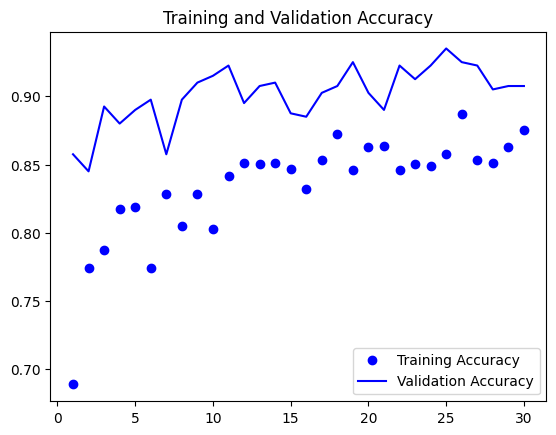

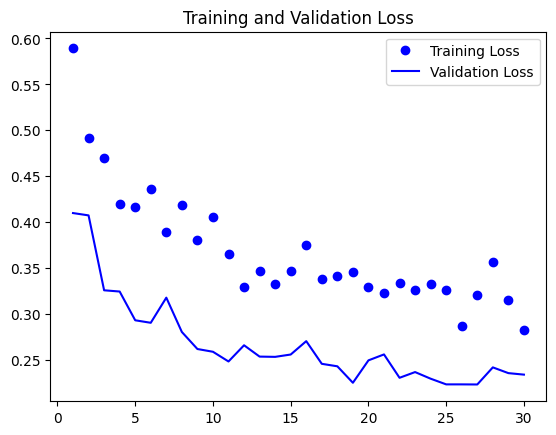

In [2]:
# Transfer Learning with VGG16 + Data Augmentation

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolution base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolution base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))

# Dataset directories
#train_dir="/content/cats_dogs_dataset/train/"
#validation_dir="/content/cats_dogs_dataset/validation/"

train_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/train/"
validation_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/validation/"

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation data should NOT be augmented
validation_datagen = ImageDataGenerator(rescale=1./255)


# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)


# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)


# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)


# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()